# This notebook contains examples on DFM and DDFMs on simulated data

In [1]:
import os, sys

cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, os.pardir))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import numpy as np
import pandas as pd
import random
from statsmodels.tsa.statespace.dynamic_factor_mq import DynamicFactorMQ as DFM
import tensorflow as tf

from models.ddfm import DDFM
from synthetic_dgp.simulate import SIMULATE

In [2]:
import logging

logger = logging.getLogger()
logger.setLevel(logging.INFO)
logging.info("Logger Level Info")
tf.get_logger().setLevel("ERROR")

INFO:root:Logger Level Info


## Simulation Settings

In [3]:
seed = 123
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
# set poly degree, if 1 then linear and the encoder structure is modified to linear single layer
poly_degree = 2
# to store common factor recovery performance
results_dfm = {"smoothed": 0, "filtered": 0}
# for DDFM we can have both state space based factor estimates and encoder based ones from training.
results_ddfm = {"smoothed": 0, "filtered": 0, "autoencoder based": 0}
results_ddfm_nnlin_dec = {
    "smoothed": 0,
    "filtered": 0,
    "autoencoder based": 0,
    "autoencoder based last neurons": 0,
}
# params sim data
n_obs = 150
r = 3
portion_missings = 0.2
# simulate data
sim = SIMULATE(seed=seed, n=150, r=r, poly_degree=poly_degree)

## Simulate Data and Compare Models

In [4]:
x = sim.simulate(n_obs, portion_missings=portion_missings)
r_f_and_nnlinf = sim.f.shape[1]
if poly_degree == 1:
    # For linear to set the following
    structure_encoder = (r_f_and_nnlinf,)
else:
    structure_encoder = (
        r_f_and_nnlinf * 6,
        r_f_and_nnlinf * 4,
        r_f_and_nnlinf * 2,
        r_f_and_nnlinf,
    )
# for nonlinear decoder
structure_encoder_nnlin = (r_f_and_nnlinf, r * 9, r * 6, r * 3, r)
structure_decoder_nnlin = (r * 3, r * 6, r * 9, r_f_and_nnlinf)

In [5]:
%%time
# estimate dfm
dyn_fact_mdl = DFM(
    pd.DataFrame(x), factors=min(r_f_and_nnlinf, x.shape[1]), factor_orders=1
)
res_dyn_fact_mdl = dyn_fact_mdl.fit(disp=1000, maxiter=1000)

EM start iterations, llf=-11404
EM converged at iteration 294, llf=-10229, convergence criterion=9.9724e-07 < tolerance=1e-06
CPU times: total: 30min 38s
Wall time: 4min 46s


In [6]:
results_dfm["smoothed"] = sim.evaluate(
    res_dyn_fact_mdl.factors["smoothed"].values, f_true=sim.f
)
results_dfm["filtered"] = sim.evaluate(
    res_dyn_fact_mdl.factors["filtered"].values, f_true=sim.f
)
pd.Series(results_dfm)

smoothed    0.767624
filtered    0.767504
dtype: float64

In [7]:
%%time
# estimate ddfm with linear decoder
deep_dyn_fact_mdl = DDFM(
    structure_encoder=structure_encoder,
    factor_order=1,
    use_bias=False,
    link="relu",
    max_iter=1000,
)
deep_dyn_fact_mdl.fit(pd.DataFrame(x), build_state_space=True)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step


INFO:DDFM:Convergence achieved in 8 iterations - new loss: 0.21170863068698914 - delta: 0.0001941593845470949 < 0.0005


CPU times: total: 45.1 s
Wall time: 38.3 s


In [8]:
results_ddfm["autoencoder based"] = sim.evaluate(
    np.mean(deep_dyn_fact_mdl.factors_ae, axis=0), f_true=sim.f
)
results_ddfm["filtered"] = sim.evaluate(
    deep_dyn_fact_mdl.factors_filtered, f_true=sim.f
)
results_ddfm["smoothed"] = sim.evaluate(
    deep_dyn_fact_mdl.factors_smoothed, f_true=sim.f
)
pd.Series(results_ddfm)

smoothed             0.892992
filtered             0.862248
autoencoder based    0.957121
dtype: float64

In [9]:
%%time
# estimate ddfm with nonlinear decoder
deep_dyn_fact_mdl_nnlin = DDFM(
    structure_encoder=structure_encoder_nnlin,
    factor_order=1,
    var_loss_weight=0,
    structure_decoder=structure_decoder_nnlin,
    use_bias=False,
    link="relu",
    max_iter=1000,
)
deep_dyn_fact_mdl_nnlin.fit(pd.DataFrame(x))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step


INFO:DDFM:iteration: 10 - new loss: 0.24228112059196902 - delta: 0.0078341675000732
INFO:DDFM:Convergence achieved in 11 iterations - new loss: 0.2422094342894266 - delta: 0.000295924458464723 < 0.0005


CPU times: total: 53.9 s
Wall time: 44.2 s


In [10]:
results_ddfm_nnlin_dec[0] = sim.evaluate(
    np.mean(deep_dyn_fact_mdl_nnlin.last_neurons, axis=0), f_true=sim.f
)
results_ddfm_nnlin_dec[1] = sim.evaluate(
    np.mean(deep_dyn_fact_mdl_nnlin.factors_ae, axis=0), f_true=sim.linear_f
)
print("last neurons", results_ddfm_nnlin_dec[0])
print("code layer against linear f", results_ddfm_nnlin_dec[1])

last neurons 0.8800636639423675
code layer against linear f 0.2558819215377104


In [11]:
%%time
# estimate ddfm with nonlinear decoder and joint var estimation
deep_dyn_fact_mdl_nnlin_jest = DDFM(
    structure_encoder=structure_encoder_nnlin,
    factor_order=1,
    var_loss_weight=1.0,
    structure_decoder=structure_decoder_nnlin,
    use_bias=False,
    link="relu",
    max_iter=1000,
)
deep_dyn_fact_mdl_nnlin_jest.fit(pd.DataFrame(x))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step


INFO:DDFM:iteration: 10 - new loss: 0.2689001262187958 - delta: 0.013039851561188698
INFO:DDFM:Convergence achieved in 12 iterations - new loss: 0.2660236656665802 - delta: 0.0003085750213358551 < 0.0005


CPU times: total: 57.8 s
Wall time: 45.9 s


In [12]:
results_ddfm_nnlin_dec[0] = sim.evaluate(
    np.mean(deep_dyn_fact_mdl_nnlin_jest.last_neurons, axis=0), f_true=sim.f
)
results_ddfm_nnlin_dec[1] = sim.evaluate(
    np.mean(deep_dyn_fact_mdl_nnlin_jest.factors_ae, axis=0), f_true=sim.linear_f
)
print("last neurons", results_ddfm_nnlin_dec[0])
print("code layer against linear f", results_ddfm_nnlin_dec[1])

last neurons 0.927919297193868
code layer against linear f 0.2514541519425562


<Axes: title={'center': 'True Factors'}>

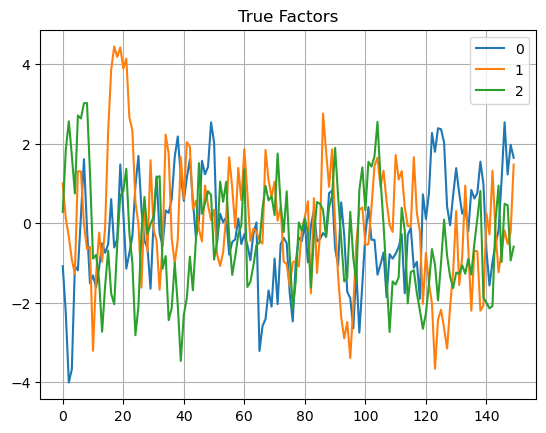

In [13]:
pd.DataFrame(sim.linear_f).plot(grid=True, title="True Factors")

<Axes: title={'center': 'Estimated Factors'}>

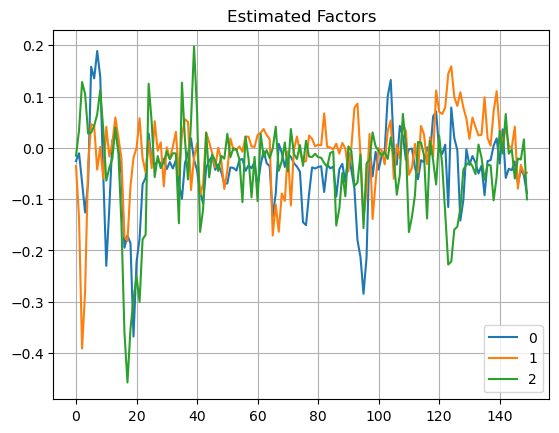

In [14]:
pd.DataFrame(np.mean(deep_dyn_fact_mdl_nnlin_jest.factors_ae, axis=0)).plot(
    grid=True, title="Estimated Factors"
)

Notes:
- Say this is one sim to showcase usage, while extensive simulations are carried out in ...
- About DDFM getting to wrong solution due to bad initialization
- About the extracted factor and identification problem, and why we can in this case evaluate based on last neurons.
- About why with linear decoder, filtered and smoothed perform worst